# Controlled Qubricks

In this tutorial, we will discuss implementing controlled variants of Qubricks.

## Controlled operations in quantum algorithms

Controlled operations are an important building block of quantum algorithms, on a par with [uncomputation](./Qubricks-Uncomputation.ipynb). For example, phase estimation algorithm relies on our ability to implement the controlled variants of the unitary we're working with.

Unlike uncomputation, however, Workbench doesn't aim to handle controlled variants of Qubricks automatically. Why?

Let's say we have a Qubrick with a `_compute` method that consists of some sequence of operations - gates and calls to other Qubricks' `compute` methods. As we've seen in the [uncomputation tutorial](./Qubricks-Uncomputation.ipynb), generating an adjoint variant of this method is often as simple as just playing these operations in reverse order, taking an adjoint of each of them. This also turns out to be the most efficient way to do uncomputation in most scenarios. Very few quantum routines have an uncompute that is more efficient than their compute, and Workbench allows you to implement a custom uncompute for these cases.

Generating an efficient controlled variant of this method, however, is not as trivial. The most straightforward way to do that - just calling the controlled version of each of the operations in the `_compute` method - turns out to be extremely inefficient in most scenarios! Most of the time, the computation done by a Qubrick has some structure that allows us to implement its controlled variant much more efficiently than the straightforward scenario.

For example, consider a common pattern we've seen in the uncomputation tutorial: a unitary conjugation operation $U^\dagger V U$ that consists of three steps:

1. Applying an operation $U$
2. Applying another operation $V$
3. Uncomputing the operation $U$, or, in other words, applying an operation $U^\dagger$

To implement the controlled variant of this operation, we can, of course, apply controlled-$U$, controlled-$V$, and finally controlled-$U^\dagger$. But it is a lot more efficient to use the sequence $U$, controlled-$V$, and $U^\dagger$, since, if the control qubits are not in the $|1...1\rangle$ state, the operations $U$ and $U^\dagger$ will just cancel each other out.

There are plenty of other optimizations that can be used when implementing controlled variants of quantum operation, depending on their structure. Furthermore, one can define a controlled variant of an operation even if some of its building blocks don't have a controlled variant defined. (We will see an example of this later in this tutorial.) Because of this, at this point Workbench trusts the algorithm designer to implement the most efficient controlled variant of their Qubrick.

## Defining controlled variant of a Qubrick

To define a controlled variant of a Qubrick, you need to add an extra argument to its `_compute` method: the qubit register that will act as the control. This argument should have a default value of `None` to allow you to call the regular variant of this Qubrick without a control register.

In the `_compute` method itself, you can handle the control register as just another variable (that might be `None`). For example, your code can have two separate code paths: one for the case when the control register is `None` (to implement the operation itself) and one for the case when the control register is a Qubits object (to implement the controlled variant of the operation). You can further distinguish the cases with different sizes of control registers if this is important for your implementation, and so on.

The following code snippet implements one- and two-qubit state preparation routines as Qubricks, showing how to implement a Qubrick that has a controlled variant defined and how to use it in the code.

The `StatePrep1Q` Qubrick implements one-qubit state preparation, acting as a Qubrick wrapper around the Ry gate.
You can see that its `_compute` method takes an additional argument `ctrl`, indicating that external code can use the controlled variant of this Qubrick.
In the code, the value `ctrl` is passed as the `cond` argument to the `ry` gate method. Under the hood, the `ry` method handles both the case of `ctrl` being `None` (the uncontrolled Ry gate) and the case of `ctrl` having an arbitrary number of qubits (the controlled Ry gate), so we don't need to make this distinction in our code.

The `StatePrep2Q` Qubrick implements two-qubit state preparation. Its `_compute` method doesn't have the `ctrl` argument, indicating that this Qubrick doesn't have a controlled variant defined. Instead, it shows how to call both controlled and uncontrolled variants of the `StatePrep1Q` Qubrick.

|reg>
|0>    0.360000+0.000000j
|1>    -0.480000-0.000000j
|2>    0.480000+0.000000j
|3>    0.640000+0.000000j


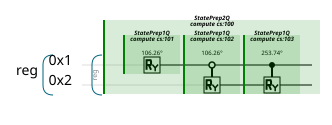

In [1]:
from math import atan2, sqrt
from psiqdk.workbench import QPU, Qubits, Qubrick, units

class StatePrep1Q(Qubrick):
    def _compute(self, reg: Qubits, amps: list[float], ctrl: Qubits | None = None):
        'Prepare a one-qubit state with the given real amplitudes'
        # Make sure that our inputs correspond to the one-qubit state preparation
        assert reg.num_qubits == 1 and len(amps) == 2
        theta = 2 * atan2(amps[1], amps[0])
        # Call the Ry gate with the control register passed as the cond argument 
        reg.ry(theta * units.rad, cond=ctrl)

class StatePrep2Q(Qubrick):
    def _compute(self, reg: Qubits, amps: list[float]):
        'Prepare a two-qubit state with the given real amplitudes'
        # Make sure that our inputs correspond to the two-qubit state preparation
        assert reg.num_qubits == 2 and len(amps) == 4

        even_amps = amps[0::2]
        odd_amps = amps[1::2]
        amp_0 = sqrt(sum(a * a for a in even_amps))
        amp_1 = sqrt(sum(a * a for a in odd_amps))
                
        one_qubit = StatePrep1Q()
        
        # Prepare the least significant qubit (LSB)
        # using uncontrolled variant of one-qubit state preparation.
        one_qubit.compute(reg[0], [amp_0, amp_1])

        # Prepare the most significant qubit, controlled on LSB=0.
        # Use the condition involving the LSB as the control for one-qubit state preparation.
        one_qubit.compute(reg[1], even_amps, ctrl=reg[0] == 0)

        # Prepare the most significant qubit, controlled on LSB=1.
        # Use the condition involving the LSB as the control for one-qubit state preparation.
        one_qubit.compute(reg[1], odd_amps,  ctrl=reg[0])

qpu = QPU(num_qubits=2)
amps = [0.36, -0.48, 0.48, 0.64]
reg = Qubits(2, "reg", qpu)

state_prep = StatePrep2Q()
state_prep.compute(reg, amps)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

The next example expands on the one- and two-qubit state preparation Qubricks, combining their logic to implement recursive state preparation algorithm as a Qubrick that calls its own controlled variant recursively.

The `_compute` method of the `StatePreparation` Qubrick takes the `ctrl` argument, indicating that it has a controlled variant defined.
When the subsequent code calls this Qubrick to prepare a state, it does not pass this argument, using the uncontrolled variant of the operation. But the recursive calls in the `_compute` method pass this argument to use controlled variants of the operation. You can see that each `_compute` method passes its entire `ctrl` argument to the recursive calls, sometimes appending a qubit from the main register to it to use more control qubits.

|reg>
|0>    0.360000+0.000000j
|1>    -0.320000-0.000000j
|2>    0.480000+0.000000j
|3>    0.320000+0.000000j
|4>    -0.320000+0.000000j
|6>    0.320000+0.000000j
|7>    -0.480000+0.000000j


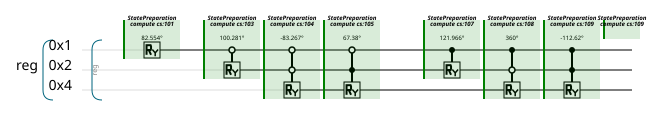

In [2]:
from math import atan2, sqrt
from psiqdk.workbench import QPU, Qubits, Qubrick, units

class StatePreparation(Qubrick):
    def _compute(self, reg: Qubits, amps: list[float], ctrl: Qubits | None = None):
        'Prepare a multi-qubit state with the given real amplitudes'
        if reg.num_qubits == 1:
            # Base case of recursion - single-qubit state preparation
            theta = 2 * atan2(amps[1], amps[0])
            # Call the Ry gate with the control register passed as the argument 
            reg.ry(theta * units.rad, cond=ctrl)
        else:
            even_amps = amps[0::2]
            odd_amps = amps[1::2]
            amp_0 = sqrt(sum(a * a for a in even_amps))
            amp_1 = sqrt(sum(a * a for a in odd_amps))

            # Prepare the least significant qubit (LSB).
            # Use the control register passed as the argument
            self.compute(reg[0], [amp_0, amp_1], ctrl=ctrl)

            # Prepare the most significant n-1 bits, controlled on LSB=0.
            # Use the control register passed as the argument plus a condition involving the LSB as the control.
            self.compute(reg[1:], even_amps, ctrl=ctrl | (reg[0] == 0))

            # Prepare the most significant n-1 bits, controlled on LSB=1.
            # Use the control register passed as the argument plus the LSB as the control.
            self.compute(reg[1:], odd_amps,  ctrl=ctrl | reg[0])

qpu = QPU(num_qubits=3)
amps = [0.36, -0.32, 0.48, 0.32, -0.32, 0, 0.32, -0.48]
reg = Qubits(3, "reg", qpu)

state_prep = StatePreparation(allow_multi_qubit_ctrl=True)
state_prep.compute(reg, amps)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

## Optimizing controlled variant of a Qubrick

In the previous example, the controlled variant of the state preparation unitary was implemented by taking the control register `ctrl` and calling each operation within it with `ctrl` as the control register. This is the most straightforward way to implement the controlled variant of a unitary. However, you can often do that much more efficiently.

The following example shows how to add controlled variant to the reflection about a quantum state example from the [uncomputation tutorial](./Qubricks-Uncomputation.ipynb#simple-dagger-adjoint). Reflection about a state is an example of a unitary conjugation operation we discussed earlier in this tutorial: it can be represented as $U^\dagger V U$, where $U$ is the adjoint of the routine that prepares the state from the $|0\rangle$ state, and $V$ is the reflection about the $|0\rangle$ state. You can see that we can implement the controlled variant of reflection about a state by controlling just the middle unitary $V$, the reflection about $|0\rangle$ state. In fact, the `USP` Qubrick we're using for state preparation doesn't even have a controlled variant defined!

|reg|ctrl|?>
|0|0|.>    0.353553+0.000000j
|0|1|.>    0.353553+0.000000j
|1|0|.>    0.353553+0.000000j
|1|1|.>    0.353553+0.000000j
|2|0|.>    0.353553+0.000000j
|2|1|.>    0.353553+0.000000j
|3|0|.>    0.353553+0.000000j
|3|1|.>    0.353553+0.000000j
|reg|ctrl|?>
|0|0|.>    0.353553-0.000000j
|0|1|.>    -0.353553-0.000000j
|1|0|.>    0.353553+0.000000j
|1|1|.>    -0.353553-0.000000j
|2|0|.>    0.353553-0.000000j
|2|1|.>    -0.353553-0.000000j
|3|0|.>    0.353553+0.000000j
|3|1|.>    0.353553+0.000000j


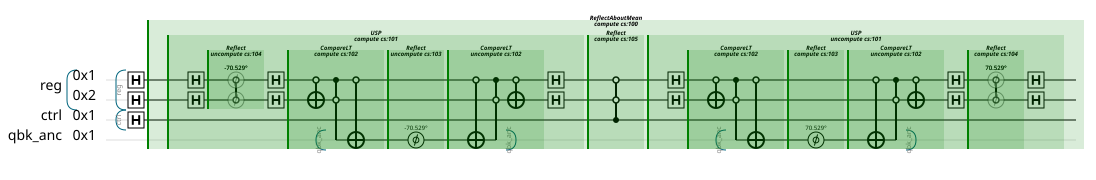

In [3]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.usp import USP

class ReflectAboutMean(Qubrick):
    def _compute(self, reg: Qubits, num_states: int, ctrl: Qubits | None = None) -> None:
        usp = USP()
        # Adjoint of state prep - applied without control!
        usp.compute(num_states, reg, dagger=True)

        # Reflection about |0⟩ - the only part applied with control
        (~reg).reflect(ctrl=ctrl)

        # State prep - applied without control!
        usp.uncompute()


qpu = QPU(num_qubits=4)
reg = Qubits(2, "reg", qpu)
ctrl = Qubits(1, "ctrl", qpu)

reflect = ReflectAboutMean()

reg.had()
ctrl.had()
qpu.print_state_vector()

# Reflect about the state |0⟩ + |1⟩ + |2⟩, conditioned on ctrl register
reflect.compute(reg, 3, ctrl=ctrl)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

## Consolidating conditions with multiple control qubits

If the code calls a controlled version of a Qubrick with a multi-qubit control register, it is often inefficient to use it as the control for each of the gates/Qubricks within that call directly. By default, Workbench consolidates multi-qubit control registers: it allocates an auxiliary qubit, uses it to compute the multi-qubit condition, and then uses that qubit as the control for gates within the controlled version of the Qubrick. This behavior can be disabled by passing the flag `allow_multi_qubit_ctrl=True` to the Qubrick during its initialization.

The following example shows this feature. It calls two variants of the built-in adder to perform controlled increment of a register. (You can learn more about Workbench adders, including the `NaiveAdd` Qubrick, in the [quantum arithmetic tutorial](./Quantum-Arithmetic.ipynb).) First, the adder is instantiated with default settings (`allow_multi_qubit_ctrl=False`). In this case, calling the controlled version of the adder with a three-qubit control register consolidates the condition into auxiliary qubit `ctrl_anc`. Then, another instance of the adder is created with the flag `allow_multi_qubit_ctrl=True`. In this case, no auxiliary qubits are allocated; each gate of the adder is just called with three extra control qubits.

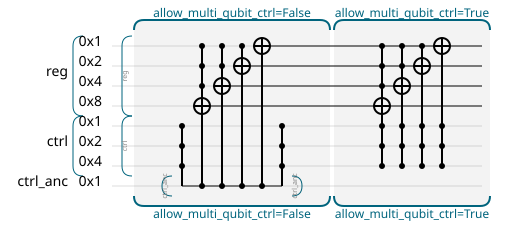

In [4]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import NaiveAdd

qpu = QPU(num_qubits=8)
reg = Qubits(4, "reg", qpu)
ctrl = Qubits(3, "ctrl", qpu)

qpu.label("allow_multi_qubit_ctrl=False")
adder1 = NaiveAdd()
adder1.compute(reg, 1, ctrl=ctrl)

qpu.label("allow_multi_qubit_ctrl=True")
adder2 = NaiveAdd(allow_multi_qubit_ctrl=True)
adder2.compute(reg, 1, ctrl=ctrl)

qpu.draw()

## Combining controlled and adjoint variants of a Qubrick

So far in this tutorial, we have seen how to define and use controlled variants of Qubricks. How can we combine that with uncomputation?

Using a controlled variant of a Qubrick means simply calling its `compute` method with an extra argument - the control register. This means that we can uncompute it by just calling `uncompute` without arguments - Workbench will figure out how to do the uncomputation for you.

The following example illustrates uncomputing controlled operations. The code uses a series of controlled increments to count the number of bits set to "1" in a four-qubit quantum register and store it in the `reg_sum` register. (You can learn more about Workbench adders, including the `NaiveAdd` Qubrick, in the [quantum arithmetic tutorial](./Quantum-Arithmetic.ipynb).) Then, it uses a controlled X gate to mark the balanced basis states, that is, the basis states that have exactly two "1" bits and two "0" bits. Finally, it uncomputes the controlled increments to return the `reg_sum` register to the $|0\rangle$ state. You can see that calling `uncompute` uncomputes controlled variants of the addition operation correctly.

|reg|sum|target>
|0|0|0>    0.250000+0.000000j
|1|0|0>    0.250000+0.000000j
|2|0|0>    0.250000+0.000000j
|3|0|1>    0.250000+0.000000j
|4|0|0>    0.250000+0.000000j
|5|0|1>    0.250000+0.000000j
|6|0|1>    0.250000+0.000000j
|7|0|0>    0.250000+0.000000j
|8|0|0>    0.250000+0.000000j
|9|0|1>    0.250000+0.000000j
|10|0|1>    0.250000+0.000000j
|11|0|0>    0.250000+0.000000j
|12|0|1>    0.250000+0.000000j
|13|0|0>    0.250000+0.000000j
|14|0|0>    0.250000+0.000000j
|15|0|0>    0.250000+0.000000j


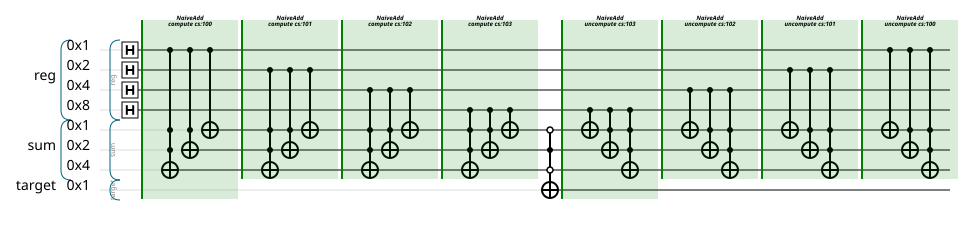

In [5]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import NaiveAdd

qpu = QPU(num_qubits=8)
n = 4
reg = Qubits(n, "reg", qpu)
reg_sum = Qubits(n.bit_length(), "sum", qpu)
target = Qubits(1, "target", qpu)

reg.had()

adder = NaiveAdd()
for q in reg:
    # Use controlled increments to count the number of "1" bits in the number
    adder.compute(reg_sum, 1, ctrl=q)
    
target.x(cond=reg_sum == n // 2)

for _ in range(n):
    # Uncompute controlled increments
    adder.uncompute()

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

Similarly, to call adjoint controlled variant of a Qubrick without calling its controlled variant, you need to pass two arguments - the control register and the `dagger=True` argument responsible for doing "daggered" computation. And if you need to define custom uncompute for your Qubrick, you can extend its definition to include a control register argument as well.

## Next steps

In this tutorial, you've learned to define and use controlled variants of Qubricks. The next tutorial will discuss another of the key benefits of using Qubricks in your code - [automatic quantum memory management](./Qubricks-Qubit-Management.ipynb).